# Text Mining Project: Biblical Genre Classification

This project aims to classify fragments of biblical text into literary genres using classical Natural Language Processing (NLP) and Machine Learning techniques.

The pipeline includes:
- Text preprocessing
- Document representation using TF-IDF
- Supervised classification using multiple models
- Evaluation and analysis of results

The goal is to assess whether linguistic patterns can be used to distinguish between different literary genres such as Narrative, Poetry, Prophetic, Epistle, and Legal texts.

In [142]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [143]:
df = pd.read_csv("bible_data_set.csv")

In [144]:
print(df.shape)
df.head()

(31102, 5)


,citation,book,chapter,verse,text
0,Genesis 1:1,Genesis,1,1,In the beginning God created the heaven and th...
1,Genesis 1:2,Genesis,1,2,"And the earth was without form, and void; and ..."
2,Genesis 1:3,Genesis,1,3,"And God said, Let there be light: and there wa..."
3,Genesis 1:4,Genesis,1,4,"And God saw the light, that it was good: and G..."
4,Genesis 1:5,Genesis,1,5,"And God called the light Day, and the darkness..."


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31102 entries, 0 to 31101
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   citation  31102 non-null  object
 1   book      31102 non-null  object
 2   chapter   31102 non-null  int64 
 3   verse     31102 non-null  int64 
 4   text      31102 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.2+ MB


In [146]:
print(df["book"].nunique())
print(sorted(df["book"].unique()))

66
['1 Chronicles', '1 Corinthians', '1 John', '1 Kings', '1 Peter', '1 Samuel', '1 Thessalonians', '1 Timothy', '2 Chronicles', '2 Corinthians', '2 John', '2 Kings', '2 Peter', '2 Samuel', '2 Thessalonians', '2 Timothy', '3 John', 'Acts', 'Amos', 'Colossians', 'Daniel', 'Deuteronomy', 'Ecclesiastes', 'Ephesians', 'Esther', 'Exodus', 'Ezekiel', 'Ezra', 'Galatians', 'Genesis', 'Habakkuk', 'Haggai', 'Hebrews', 'Hosea', 'Isaiah', 'James', 'Jeremiah', 'Job', 'Joel', 'John', 'Jonah', 'Joshua', 'Jude', 'Judges', 'Lamentations', 'Leviticus', 'Luke', 'Malachi', 'Mark', 'Matthew', 'Micah', 'Nahum', 'Nehemiah', 'Numbers', 'Obadiah', 'Philemon', 'Philippians', 'Proverbs', 'Psalms', 'Revelation', 'Romans', 'Ruth', 'Song of Solomon', 'Titus', 'Zechariah', 'Zephaniah']


In [147]:
book_to_genre = {
    "Genesis": "Narrative",
    "Exodus": "Narrative",
    "Matthew": "Narrative",
    "Acts": "Narrative",

    "Psalms": "Poetry",
    "Proverbs": "Poetry",
    "Ecclesiastes": "Poetry",

    "Isaiah": "Prophetic",
    "Jeremiah": "Prophetic",
    "Ezekiel": "Prophetic",
    "Revelation": "Prophetic",

    "Romans": "Epistle",
    "1 Corinthians": "Epistle",
    "Galatians": "Epistle",

    "Leviticus": "Legal",
    "Deuteronomy": "Legal"
}

In [148]:
selected_books = list(book_to_genre.keys())

available_books = sorted(df["book"].unique())
missing_books = [book for book in selected_books if book not in available_books]

print("Number of books selected:", len(selected_books))
print("Missing books:", missing_books)

Number of books selected: 16
Missing books: []


In [149]:
df_filtered = df[df["book"].isin(selected_books)].copy()

print("Original size:", df.shape)
print("Filtered size:", df_filtered.shape)

df_filtered.head()

Original size: (31102, 5)
Filtered size: (15592, 5)


,citation,book,chapter,verse,text
0,Genesis 1:1,Genesis,1,1,In the beginning God created the heaven and th...
1,Genesis 1:2,Genesis,1,2,"And the earth was without form, and void; and ..."
2,Genesis 1:3,Genesis,1,3,"And God said, Let there be light: and there wa..."
3,Genesis 1:4,Genesis,1,4,"And God saw the light, that it was good: and G..."
4,Genesis 1:5,Genesis,1,5,"And God called the light Day, and the darkness..."


In [150]:
df_filtered["label"] = df_filtered["book"].map(book_to_genre)

df_filtered[["book", "label"]].drop_duplicates().sort_values("book")

,book,label
28364,1 Corinthians,Epistle
26924,Acts,Narrative
4893,Deuteronomy,Legal
17316,Ecclesiastes,Poetry
1533,Exodus,Narrative
20465,Ezekiel,Prophetic
29058,Galatians,Epistle
0,Genesis,Narrative
17655,Isaiah,Prophetic
18947,Jeremiah,Prophetic


In [151]:
df_filtered = df_filtered.sort_values(["book", "chapter", "verse"]).reset_index(drop=True)

## Dataset Construction

The original dataset contains individual verses from the Bible. However, single verses are often too short to capture meaningful linguistic patterns.

To address this, verses are grouped into fragments of 4 consecutive verses. Each fragment is assigned a label corresponding to its literary genre.

This allows the model to learn more contextual and stylistic features.

In [152]:
def create_fragments(dataframe, window_size=4):
    samples = []

    for book in dataframe["book"].unique():
        sub = dataframe[dataframe["book"] == book].reset_index(drop=True)

        for i in range(0, len(sub) - window_size + 1, window_size):
            chunk = sub.iloc[i:i+window_size]

            text = " ".join(chunk["text"].astype(str).tolist())
            text = text.replace("\n", " ").strip()

            label = chunk["label"].iloc[0]

            samples.append({
                "text": text,
                "label": label,
                "book": book
            })

    return pd.DataFrame(samples)

In [153]:
dataset = create_fragments(df_filtered, window_size=4)

print("New dataset:", dataset.shape)
dataset.head()

New dataset: (3892, 3)


,text,label,book
0,Paul called to be an apostle of Jesus Christ t...,Epistle,1 Corinthians
1,"That in every thing ye are enriched by him, in...",Epistle,1 Corinthians
2,"God is faithful, by whom ye were called unto t...",Epistle,1 Corinthians
3,Is Christ divided? was Paul crucified for you?...,Epistle,1 Corinthians
4,"For Christ sent me not to baptize, but to prea...",Epistle,1 Corinthians


In [154]:
dataset["label"].value_counts()

,count
label,
Narrative,1204
Prophetic,1083
Poetry,898
Legal,453
Epistle,254


In [155]:
min_size = dataset["label"].value_counts().min()
print("Minimum size per class:", min_size)

Minimum size per class: 254


In [156]:
dataset_balanced = (
    dataset.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min_size, random_state=42))
    .reset_index(drop=True)
)

dataset_balanced["label"].value_counts()

/tmp/ipykernel_596/889061839.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_size, random_state=42))


,count
label,
Epistle,254
Legal,254
Narrative,254
Poetry,254
Prophetic,254


The dataset has been balanced so that all genres contain the same number of samples. This avoids bias in the classification models.

Each sample consists of a short text fragment and its corresponding genre label.

In [157]:
dataset_balanced.to_csv("bible_genre_dataset_full.csv", index=False)
dataset_balanced[["text", "label"]].to_csv("bible_genre_dataset.csv", index=False)

In [158]:
print(dataset_balanced.shape)

(1270, 3)


In [159]:
dataset_balanced.iloc[0]["text"]

'If then I do that which I would not, I consent unto the law that it is good.   Now then it is no more I that do it, but sin that dwelleth in me.   For I know that in me (that is, in my flesh,) dwelleth no good thing: for to will is present with me; but how to perform that which is good I find not.   For the good that I would I do not: but the evil which I would not, that I do.'

In [160]:
dataset_balanced["label"].value_counts()

,count
label,
Epistle,254
Legal,254
Narrative,254
Poetry,254
Prophetic,254


## Text Preprocessing

Basic preprocessing is applied:
- Lowercasing
- Removing punctuation
- Removing extra spaces

This step standardizes the text and reduces noise while keeping meaningful information.

In [161]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.strip()

In [162]:
dataset_balanced["clean_text"] = dataset_balanced["text"].apply(clean_text)

dataset_balanced[["text", "clean_text"]].head()

,text,clean_text
0,"If then I do that which I would not, I consent...",if then i do that which i would not i consent ...
1,Because the foolishness of God is wiser than m...,because the foolishness of god is wiser than m...
2,For he that speaketh in an unknown tongue spea...,for he that speaketh in an unknown tongue spea...
3,"It was said unto her, The elder shall serve th...",it was said unto her the elder shall serve the...
4,"And when James, Cephas, and John, who seemed t...",and when james cephas and john who seemed to b...


In [163]:
X = dataset_balanced["clean_text"]
y = dataset_balanced["label"]

In [164]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## TF-IDF

Texts are transformed into numerical vectors using TF-IDF.

This representation assigns higher importance to words that are frequent in a document but rare across the corpus, making it suitable for capturing discriminative features.

In [165]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [166]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (1016, 13620)
Test shape: (254, 13620)


In [167]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": LinearSVC()
}

## Model Training

Three classical machine learning models are evaluated:

- Naive Bayes
- Logistic Regression
- Linear Support Vector Machine (SVM)

These models provide a good balance between simplicity and performance.

In [168]:
from sklearn.metrics import accuracy_score, classification_report

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

    print(f"\n--- {name} ---")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


--- Naive Bayes ---
Accuracy: 0.8818897637795275
              precision    recall  f1-score   support

     Epistle       0.86      0.96      0.91        51
       Legal       0.86      0.96      0.91        50
   Narrative       0.87      0.76      0.81        51
      Poetry       0.95      0.78      0.86        51
   Prophetic       0.89      0.94      0.91        51

    accuracy                           0.88       254
   macro avg       0.88      0.88      0.88       254
weighted avg       0.89      0.88      0.88       254


--- Logistic Regression ---
Accuracy: 0.8779527559055118
              precision    recall  f1-score   support

     Epistle       0.89      0.94      0.91        51
       Legal       0.88      0.88      0.88        50
   Narrative       0.82      0.80      0.81        51
      Poetry       0.94      0.88      0.91        51
   Prophetic       0.87      0.88      0.87        51

    accuracy                           0.88       254
   macro avg       0.88

## Results Analysis

All models achieve strong performance, with accuracy values around 0.88–0.89.

The Linear SVM model achieves the highest accuracy, suggesting that it is better suited for handling high-dimensional TF-IDF representations.

Naive Bayes also performs competitively, indicating that word distributions are highly informative for this task.

Narrative texts are slightly harder to classify, likely due to their more general vocabulary and overlap with other genres.

In [169]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

,Model,Accuracy
2,Linear SVM,0.889764
0,Naive Bayes,0.881890
1,Logistic Regression,0.877953


The confusion matrix provides insight into which genres are more frequently confused.

This helps identify overlapping linguistic patterns between genres.

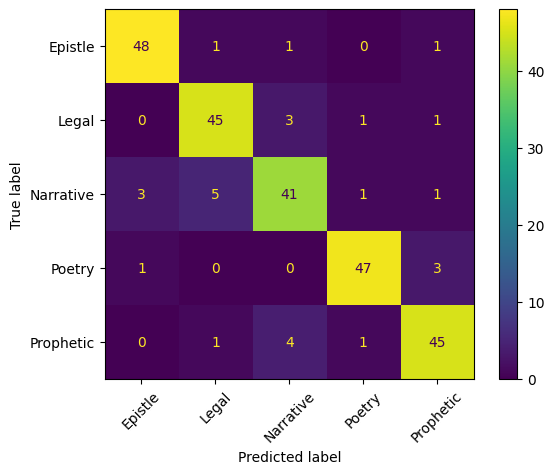

In [170]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = LinearSVC()
best_model.fit(X_train_tfidf, y_train)
y_pred = best_model.predict(X_test_tfidf)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.show()

### Observations

- Epistle and Poetry are classified with high accuracy.
- Narrative texts show more confusion with other genres.
- Some overlap exists between Narrative, Legal, and Prophetic texts.

This suggests that certain genres share common linguistic structures.

## Feature Importance

To better understand the model, we analyze the most important words associated with each genre.

These words help explain how the model differentiates between categories.

In [171]:
feature_names = vectorizer.get_feature_names_out()

coef = best_model.coef_

labels = best_model.classes_

for i, label in enumerate(labels):
    top10 = np.argsort(coef[i])[-10:]
    print(f"\nTop words for {label}:")
    print([feature_names[j] for j in top10])


Top words for Epistle:
['if', 'things', 'we', 'salute', 'you', 'now', 'of god', 'not', 'but', 'christ']

Top words for Legal:
['which', 'priest', 'offering', 'land', 'the priest', 'unclean', 'shalt not', 'lord thy', 'your', 'thy god']

Top words for Narrative:
['him', 'unto him', 'father', 'had', 'said unto', 'begat', 'and when', 'pharaoh', 'and', 'said']

Top words for Poetry:
['wicked', 'strength', 'the wicked', 'for ever', 'heart', 'selah', 'me', 'praise', 'ever', 'my']

Top words for Prophetic:
['jeremiah', 'judah', 'lord god', 'thus saith', 'of', 'shall', 'and', 'behold', 'saith', 'saith the']


### Refined Interpretation of Feature Importance

After removing non-informative words (e.g., “and”, “of”, “we”), more meaningful patterns emerge:

- **Epistles**: doctrinal and argumentative language (christ, god, you, not, but, salute)
- **Legal texts**: characterized by prescriptive language (priest, offering, unclean, shalt not, thy god, lord thy)
- **Narrative texts**: storytelling and dialogue (said, said unto, father, pharaoh, begat, unto him)
- **Poetry**: emotional and symbolic vocabulary (wicked, heart, praise, selah, for ever, strength)
- **Prophetic texts**: marked by declarative expressions (thus saith, saith the, behold, judah, lord god)

These results confirm that the model captures stylistic differences between genres rather than relying on random word frequency.

## Error Analysis

We analyze misclassified examples to understand the limitations of the model.

In [172]:
errors = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred
})

errors = errors[errors["true"] != errors["pred"]]

errors.head(30)

,text,true,pred
406,and he buried him in a valley in the land of m...,Legal,Narrative
588,and lot lifted up his eyes and beheld all the ...,Narrative,Legal
1228,bring no more vain oblations incense is an abo...,Prophetic,Legal
88,and when he had given thanks he brake it and s...,Epistle,Narrative
191,for this thou shalt not commit adultery thou s...,Epistle,Legal
536,the enemy said i will pursue i will overtake i...,Narrative,Poetry
773,to have respect of persons is not good for for...,Poetry,Epistle
1165,for in one hour so great riches is come to nou...,Prophetic,Narrative
369,and he put the mitre upon his head also upon t...,Legal,Narrative
515,and it shall come to pass if they will not bel...,Narrative,Legal


### Observations

Misclassifications often occur when:
- Texts contain mixed stylistic features
- Narrative language appears within other genres
- Certain expressions are shared across genres

This indicates that genre boundaries are not always strictly defined and can overlap in practice.

## Qualitative Evaluation on Real Examples

To further validate the model, several real text fragments from the dataset were analyzed, including their original book, true genre, and predicted genre.

In [173]:
# We add a unique ID to the original dataset
dataset_balanced = dataset_balanced.reset_index().rename(columns={"index": "id"})

# We create train/test keeping the ID
X = dataset_balanced["clean_text"]
y = dataset_balanced["label"]
ids = dataset_balanced["id"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# We create a test dataframe with ID
test_df = pd.DataFrame({
    "id": id_test,
    "text": X_test,
    "label": y_test
})


test_df = test_df.merge(
    dataset_balanced[["id", "book"]],
    on="id",
    how="left"
)

# We take some examples
sample_examples = test_df.sample(20, random_state=42)

results = []

for _, row in sample_examples.iterrows():
    pred = predict_genre(row["text"], best_model, vectorizer)

    results.append({
        "text": row["text"][:200] + "...",
        "book": row["book"],
        "true_genre": row["label"],
        "predicted": pred
    })

demo_df = pd.DataFrame(results)
demo_df

,text,book,true_genre,predicted
0,it shall be for the priests that are sanctifie...,Ezekiel,Prophetic,Prophetic
1,and the sons of simeon jemuel and jamin and oh...,Genesis,Narrative,Narrative
2,and because he loved thy fathers therefore he ...,Deuteronomy,Legal,Legal
3,let your women keep silence in the churches fo...,1 Corinthians,Epistle,Epistle
4,therefore the princes said unto the king we be...,Jeremiah,Prophetic,Prophetic
5,wherefore have ye not eaten the sin offering i...,Leviticus,Legal,Legal
6,and the lord god called unto adam and said unt...,Genesis,Narrative,Narrative
7,hold not thy peace o god of my praise for the ...,Psalms,Poetry,Poetry
8,deliver me from all my transgressions make me ...,Psalms,Poetry,Poetry
9,and when he had given thanks he brake it and s...,1 Corinthians,Epistle,Narrative


## Final Conclusions

The qualitative evaluation using real biblical fragments confirms that the model performs consistently with the quantitative results.

Most examples are correctly classified, particularly in genres with strong and distinctive linguistic patterns:

- **Legal texts** (e.g., Deuteronomy, Leviticus) are reliably identified due to their prescriptive structure and ritual vocabulary.
- **Prophetic texts** (e.g., Jeremiah, Ezekiel, Revelation) are accurately classified thanks to their declarative expressions such as “thus saith the Lord”.
- **Poetry** (e.g., Psalms) is clearly distinguished by its emotional and symbolic language.
- **Epistles** (e.g., Corinthians, Galatians) are well detected when they contain doctrinal or argumentative expressions.
- **Narrative texts** (e.g., Genesis, Exodus) are generally well classified, especially when they include storytelling patterns.

However, some misclassifications are observed:

- A fragment from **1 Corinthians (Epistle)** is classified as Narrative due to the presence of narrative-like expressions such as “and when he had…”.
- A **Legal text (Deuteronomy)** is classified as Narrative, likely because it describes concrete elements in a descriptive way rather than prescriptive rules.
- A **Prophetic fragment (Isaiah)** is classified as Legal, possibly due to the presence of ritual or normative vocabulary such as “oblations” and “incense”.

These errors highlight an important limitation: **some biblical passages exhibit mixed stylistic features**, making strict genre boundaries difficult to define.

Overall, the model demonstrates that literary genres can be effectively distinguished using TF-IDF representations and classical machine learning techniques. Moreover, the results suggest that the model captures meaningful stylistic patterns rather than relying on isolated keywords.

This supports the idea that linguistic structure and vocabulary are strong indicators of genre, even in complex and historically rich texts such as the Bible.